# mountain_2layer analysis (h-NUMO `mountain_2layer` test case)

Chen (2025, QJRMS, 10.1002/qj.4994), Sec 5.3 / Figs 7-10: two-layer zonal
flow over mountain topography.

Produces:
1. Lon-lat thickness/speed maps for both layers at the final snapshot, with
   the mountain peak marked (Fig 7 analog -- h-NUMO's VTK output has no
   vorticity field, so thickness and speed are used instead).
2. Mass conservation over time, from h-NUMO's own `mass_mlswe.cons` file
   (Fig 10 analog).
3. **Outcropping monitor**: min/max layer-2 (bottom, denser) thickness over
   time. Chen's paper reports this layer's thickness crashing through zero
   within ~15h without an artificial-potential-energy stabilization term
   that h-NUMO does not currently implement -- this is the direct check for
   whether/when that happens in a given run.

In [1]:
import sys, os, glob, re
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))
from numo_vtk import read_vtk_ascii, plot_latlon_map, read_mass_cons, snapshot_time_hours

%matplotlib inline

In [4]:
# ---------------- SETTINGS ----------------
RUNDIR = '/Users/yao/Documents/Code/h-NUMO/output/sphere/mountain_2layer/'
FPREFIX_TEMPLATE = 'mlswe_sphere_*_dg_rk35_l{layer:03d}_'
TIME_RESTART_HOURS = 0.5    # time_restart in numo3d.in
MOUNTAIN_LON_DEG = 270.0 - 360.0  # olonc = 3*pi/2 -> -90 deg (lambda_c in Chen's paper)
MOUNTAIN_LAT_DEG = 30.0           # olatc = pi/6
# -------------------------------------------

def find_snapshots(rundir, layer):
    pattern = os.path.join(rundir, FPREFIX_TEMPLATE.format(layer=layer) + '*.vtk')
    files = sorted(glob.glob(pattern))
    idx = [int(re.search(r'_(\d+)\.vtk$', f).group(1)) for f in files]
    order = np.argsort(idx)
    files, idx = [files[i] for i in order], [idx[i] for i in order]
    # dt (bcl time step) is embedded in the filename itself, e.g.
    # "mlswe_sphere_400.0000_dg_rk35_...". Snapshot spacing is irestart*dt
    # (irestart = NINT(time_restart_seconds/dt)), which only equals
    # TIME_RESTART_HOURS exactly when dt evenly divides 1800s -- see
    # numo_vtk.snapshot_time_hours.
    dt_seconds = float(re.search(r'_(\d+\.\d+)_dg', files[0]).group(1)) if files else None
    return files, idx, dt_seconds

files1, idx1, dt_seconds = find_snapshots(RUNDIR, 1)
files2, idx2, _ = find_snapshots(RUNDIR, 2)
print(f"layer 1: {len(files1)} snapshots, layer 2: {len(files2)} snapshots")

layer 1: 44 snapshots, layer 2: 44 snapshots


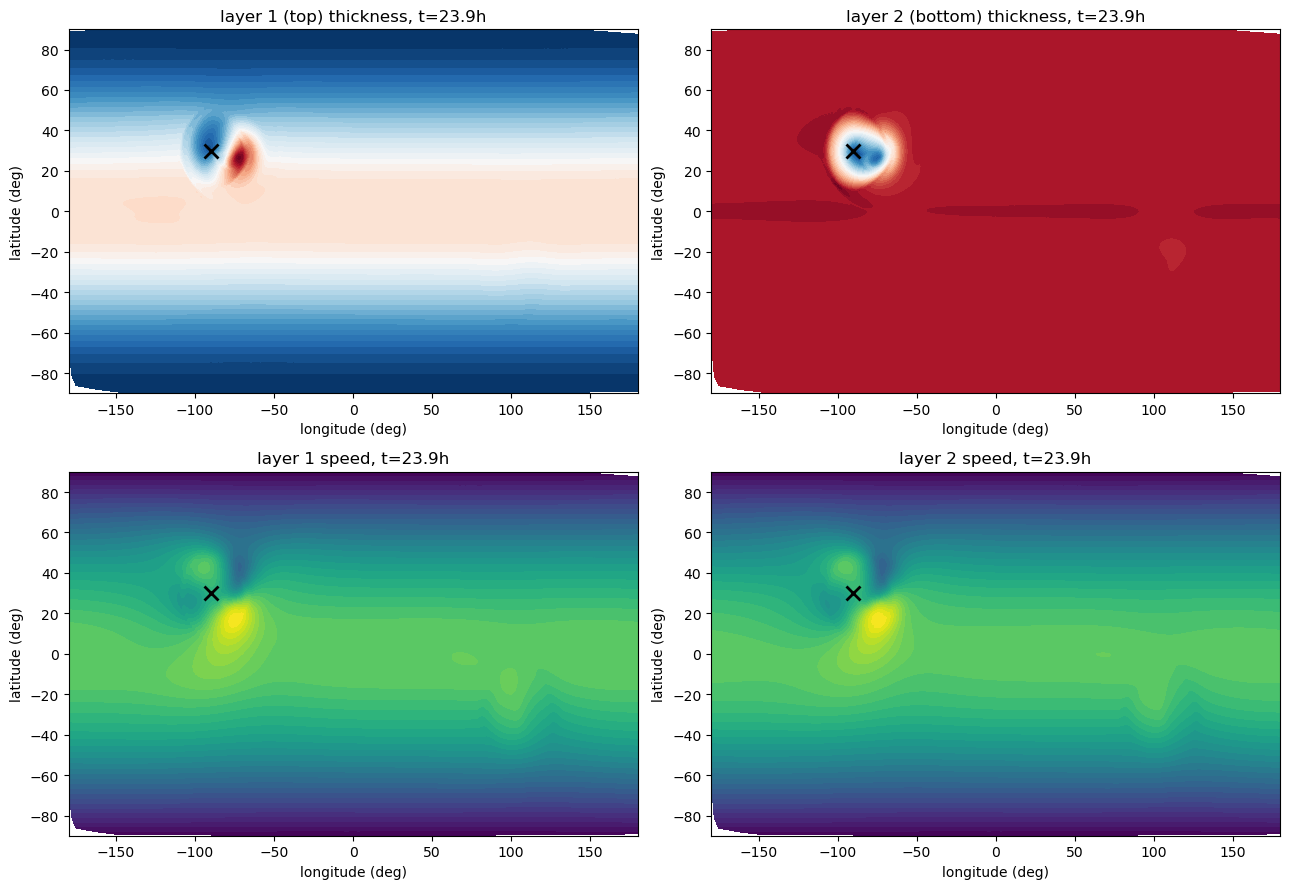

In [5]:
# ---- 1. Final-snapshot maps ----
d1 = read_vtk_ascii(files1[-1], fields=['h', 'u', 'v'])
d2 = read_vtk_ascii(files2[-1], fields=['h', 'u', 'v'])
t_final = snapshot_time_hours(idx1[-1], dt_seconds, TIME_RESTART_HOURS)
speed1 = np.hypot(d1['u'], d1['v'])
speed2 = np.hypot(d2['u'], d2['v'])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
mp = (MOUNTAIN_LON_DEG, MOUNTAIN_LAT_DEG)
plot_latlon_map(axes[0][0], d1['lon'], d1['lat'], d1['h'],
                 title=f'layer 1 (top) thickness, t={t_final:.1f}h', mark_point=mp)
plot_latlon_map(axes[0][1], d2['lon'], d2['lat'], d2['h'],
                 title=f'layer 2 (bottom) thickness, t={t_final:.1f}h', mark_point=mp)
plot_latlon_map(axes[1][0], d1['lon'], d1['lat'], speed1, cmap='viridis',
                 title=f'layer 1 speed, t={t_final:.1f}h', mark_point=mp)
plot_latlon_map(axes[1][1], d2['lon'], d2['lat'], speed2, cmap='viridis',
                 title=f'layer 2 speed, t={t_final:.1f}h', mark_point=mp)
fig.tight_layout()

Final relative mass change: layer 1: 0.000e+00, layer 2: 0.000e+00


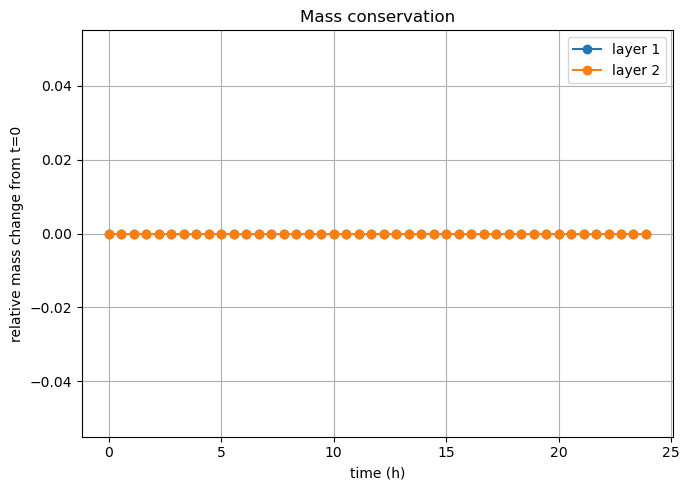

In [6]:
# ---- 2. Mass conservation, from h-NUMO's own diagnostic file ----
cons_path = os.path.join(RUNDIR, 'mass_mlswe.cons')
if os.path.exists(cons_path):
    t_mass, mass = read_mass_cons(cons_path, dt_seconds, nlayers=2)
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    for layer in range(mass.shape[1]):
        rel = (mass[:, layer] - mass[0, layer]) / mass[0, layer]
        ax2.plot(t_mass, rel, '-o', label=f'layer {layer + 1}')
    ax2.set_xlabel('time (h)'); ax2.set_ylabel('relative mass change from t=0')
    ax2.set_title('Mass conservation'); ax2.legend(); ax2.grid(True)
    fig2.tight_layout()
    print("Final relative mass change: " + ", ".join(
        f"layer {l+1}: {(mass[-1,l]-mass[0,l])/mass[0,l]:.3e}" for l in range(mass.shape[1])))
else:
    print(f"No mass_mlswe.cons found at {cons_path}, skipping mass-conservation plot")

Layer 2 thickness range over the run: min=1503.9 m at t=0.0h, max=3619.7 m
No outcropping detected in this run (layer 2 thickness stayed positive).


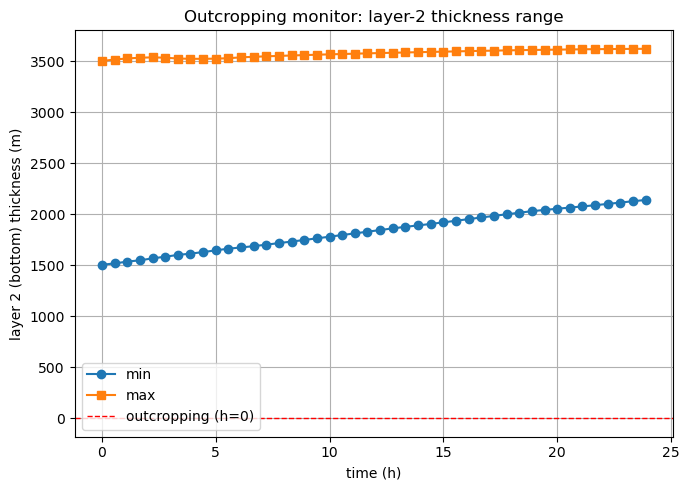

In [7]:
# ---- 3. Outcropping monitor: min/max layer-2 thickness vs time ----
times2, hmin2, hmax2 = [], [], []
for f, idx in zip(files2, idx2):
    d = read_vtk_ascii(f, fields=['h'])
    times2.append(snapshot_time_hours(idx, dt_seconds, TIME_RESTART_HOURS))
    hmin2.append(d['h'].min())
    hmax2.append(d['h'].max())

fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.plot(times2, hmin2, '-o', label='min')
ax3.plot(times2, hmax2, '-s', label='max')
ax3.axhline(0, color='r', linestyle='--', linewidth=1, label='outcropping (h=0)')
ax3.set_xlabel('time (h)'); ax3.set_ylabel('layer 2 (bottom) thickness (m)')
ax3.set_title('Outcropping monitor: layer-2 thickness range')
ax3.legend(); ax3.grid(True)
fig3.tight_layout()

print(f"Layer 2 thickness range over the run: min={min(hmin2):.1f} m at "
      f"t={times2[int(np.argmin(hmin2))]:.1f}h, max={max(hmax2):.1f} m")
if min(hmin2) <= 0:
    print("*** OUTCROPPING DETECTED: layer 2 thickness reached zero or below. ***")
else:
    print("No outcropping detected in this run (layer 2 thickness stayed positive).")